In [1]:
!pip install matplotlib scikit-learn numpy pandas

In [10]:
from scikit_learn_utils import fetch_bitcoin_data, preprocess_data, train_model, evaluate_model, plot_predictions
import pandas as pd
from sklearn.preprocessing import StandardScaler



In [11]:
# Step 1: Fetch Bitcoin data
df = fetch_bitcoin_data(days=365)
df.head()

Fetching Bitcoin price data...
Successfully fetched 366 days of Bitcoin price data.


,price
date,
2024-05-19,66912.618614
2024-05-20,66252.712596
2024-05-21,71430.297002
2024-05-22,70189.835818
2024-05-23,69181.200857


In [12]:
def create_features_from_lags(df, lags=5):
    """
    Create lag features for time series prediction.
    """
    for i in range(1, lags + 1):
        df[f'lag_{i}'] = df['price'].shift(i)
    df['target'] = df['price'].shift(-1)
    df.dropna(inplace=True)
    return df

def preprocess_data(df):
    df = create_features_from_lags(df, lags=5)

    X = df[[f'lag_{i}' for i in range(1, 6)]]
    y = df['target']

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Time-based split
    split_index = int(len(df) * 0.8)
    X_train, X_test = X_scaled[:split_index], X_scaled[split_index:]
    y_train, y_test = y[:split_index], y[split_index:]

    return X_train, X_test, y_train, y_test, scaler


In [13]:
df['price_shifted'] = df['price'].shift(-1)


In [14]:
# Step 2: Preprocess the data
X_train, X_test, y_train, y_test, scaler = preprocess_data(df)



In [15]:
# Step 3: Train the model
model = train_model(X_train, y_train)

In [16]:
# Step 4: Evaluate model
results = evaluate_model(model, X_test, y_test)
print("Mean Squared Error:", results['mse'])
print("R2 Score:", results['r2_score'])

Mean Squared Error: 24403127.177371316
R2 Score: 0.61226813470792


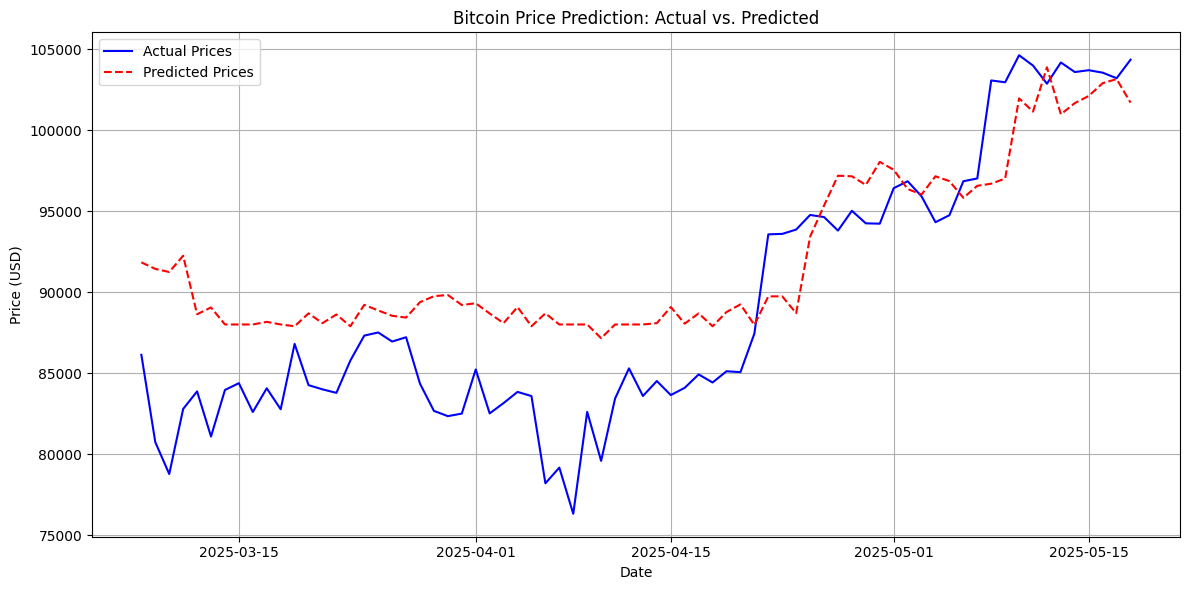

In [17]:
# Step 5: Visualize predictions
plot_predictions(y_test, results['predictions'])